# ĐỒ ÁN CUỐI KỲ
## Học phần: Toán Ứng dụng & Thống kê
### Đề tài: Ứng dụng xích Markov trong mô hình hóa và dự báo trạng thái thị trường tài chính

| | |
|---|---|
| **Sinh viên** | Nguyễn Thế Hiển |
| **MSSV** | 22127107 |
| **Đối tượng** | Chỉ số S&P 500 (`^GSPC`) |
| **Thời gian mẫu** | 02/01/2019 – 11/08/2026 (> 5 năm) |
| **Công cụ** | Python (`pandas`, `numpy`, `matplotlib`) |

> **Tuân thủ đề bài:** thư viện chỉ dùng để đọc/xử lý dữ liệu và trực quan hóa. Các bước Lab (ước lượng $P$, lũy thừa $P^n$, phân phối dừng) được **tự cài đặt**, không dùng thư viện Markov chuyên dụng.

### Tóm tắt (Abstract)
Đồ án xây dựng xích Markov thời gian rời rạc 3 trạng thái (Bear–Sideway–Bull) trên log-return hàng ngày của S&P 500. Ngưỡng trạng thái được biện luận từ $(\mu,\sigma)$ của mẫu và kiểm định độ nhạy theo $k$. Từ đó ước lượng ma trận chuyển $\hat P$, dự báo phân phối $v_t=v_0P^t$ với $t\in\{1,5,20\}$, và giải phân phối dừng $\pi$ bằng cả hệ tuyến tính lẫn trị riêng. Kết quả cho thấy Sideway chiếm ưu thế dài hạn; giả định Markov bậc 1 chỉ là xấp xỉ (có dấu hiệu bộ nhớ). Phần Bonus mở rộng không gian trạng thái 6 chiều kết hợp **biến động giá × khối lượng**, gắn rủi ro thanh khoản vào mô hình.

### Mục lục
1. Cơ sở lý thuyết  
2. Phần 1 — Tiền xử lý dữ liệu & tập trạng thái  
3. Phần 2 — Xây dựng mô hình xích Markov  
4. Phần 3 — Dự báo & phân phối dừng  
5. Phần 4 — Phân tích chuyên sâu & mở rộng  
6. Bonus — Trạng thái đa chiều (return × volume)  
7. Kết luận & tài liệu tham khảo

## 1. Cơ sở lý thuyết

Xích Markov thời gian rời rạc $\{X_n\}_{n\ge 0}$ trên không gian trạng thái hữu hạn $S=\{0,1,2\}$ thỏa **tính Markov**:

$$
\mathbb{P}(X_{n+1}=j\mid X_n=i,X_{n-1},\ldots,X_0)=\mathbb{P}(X_{n+1}=j\mid X_n=i)=p_{ij}.
$$

Ma trận chuyển $P=(p_{ij})_{i,j\in S}$ là **stochastic**: $p_{ij}\ge 0$ và $\sum_j p_{ij}=1$ với mọi $i$.

Nếu $v_0$ là phân phối ban đầu (vector hàng), phân phối tại bước $t$ là

$$
v_t = v_0 P^{t}.
$$

Với xích hữu hạn, bất khả quy và không tuần hoàn, tồn tại duy nhất phân phối dừng $\pi$ thỏa

$$
\pi P=\pi,\qquad \sum_{i\in S}\pi_i=1.
$$

$\pi$ còn là eigenvector trái ứng với trị riêng $1$ của $P$. Trong đồ án, $X_t$ là chế độ thị trường ngày $t$ suy ra từ log-return (và volume ở phần Bonus).

## 2. Phần 1 — Tiền xử lý dữ liệu và tập trạng thái

### 2.1. Nguồn dữ liệu & làm sạch
- Chỉ số **S&P 500** (đề bài khuyến khích), nguồn Yahoo Finance.
- File nộp: `22127107-NguyenTheHien.csv` (cột `Date, Open, High, Low, Close, Volume`).
- Quy trình làm sạch: sắp xếp theo thời gian, loại trùng ngày, loại dòng thiếu `Close`/`Volume`, tính log-return và loại quan sát đầu (không có $P_{t-1}$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.grid': True,
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 110,
})

DATA_PATH = '22127107-NguyenTheHien.csv'
raw = pd.read_csv(DATA_PATH, parse_dates=['Date'])

print('=== Kiểm tra & làm sạch ===')
print('Số dòng thô           :', len(raw))
print('Trùng Date            :', int(raw['Date'].duplicated().sum()))
print('Thiếu Close/Volume    :', int(raw[['Close', 'Volume']].isna().sum().sum()))

df = (raw
      .drop_duplicates(subset=['Date'])
      .dropna(subset=['Close', 'Volume'])
      .sort_values('Date')
      .reset_index(drop=True))

print('Số dòng sau làm sạch  :', len(df))
print('Khoảng thời gian      :', df['Date'].min().date(), '→', df['Date'].max().date())
print('Số năm xấp xỉ         :', round((df['Date'].max() - df['Date'].min()).days / 365.25, 2))
assert (df['Date'].max() - df['Date'].min()).days / 365.25 >= 5, 'Mẫu chưa đủ 5 năm!'
display(df.head())

=== Kiểm tra & làm sạch ===
Số dòng thô           : 1912
Trùng Date            : 0
Thiếu Close/Volume    : 0
Số dòng sau làm sạch  : 1912
Khoảng thời gian      : 2019-01-02 → 2026-08-11
Số năm xấp xỉ         : 7.61


,Date,Open,High,Low,Close,Volume
0,2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
1,2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3858830000
2,2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4234140000
3,2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4133120000
4,2019-01-08,2568.110107,2579.820068,2547.560059,2574.409912,4120060000


### 2.2. Log-return hàng ngày

$$
R_t=\ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Log-return có tính cộng theo thời gian và xấp xỉ return đơn khi biến động nhỏ — phù hợp để phân loại chế độ ngắn hạn.

Thống kê mô tả R_t:


,Thống kê,Giá trị
0,N,1911.000000
1,μ,0.000588
2,σ,0.012331
3,Min,-0.127652
4,Q01,-0.034487
5,Median,0.000951
6,Q99,0.029354
7,Max,0.090895
8,Skew,-0.665289
9,Kurtosis,15.642554


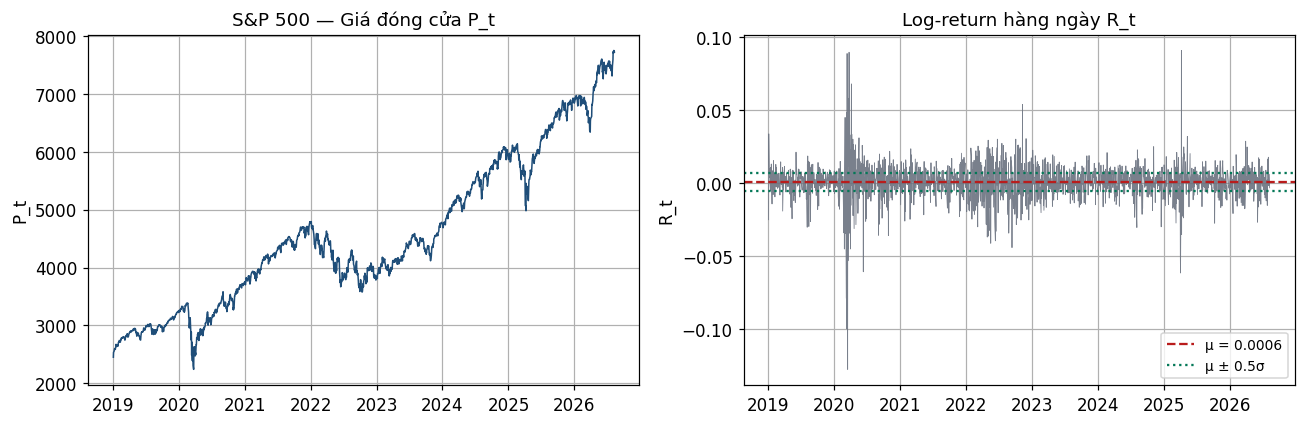

In [2]:
df['Pt'] = df['Close'].astype(float)
df['Rt'] = np.log(df['Pt'] / df['Pt'].shift(1))
df = df.dropna(subset=['Rt']).reset_index(drop=True)

mu = float(df['Rt'].mean())
sigma = float(df['Rt'].std(ddof=1))
q01, q50, q99 = df['Rt'].quantile([0.01, 0.50, 0.99])

stats = pd.DataFrame({
    'Thống kê': ['N', 'μ', 'σ', 'Min', 'Q01', 'Median', 'Q99', 'Max', 'Skew', 'Kurtosis'],
    'Giá trị': [
        len(df), mu, sigma, df['Rt'].min(), q01, q50, q99, df['Rt'].max(),
        df['Rt'].skew(), df['Rt'].kurtosis()
    ]
})
print('Thống kê mô tả R_t:')
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df['Date'], df['Pt'], color='#1f4e79', lw=1)
ax[0].set_title('S&P 500 — Giá đóng cửa P_t')
ax[0].set_ylabel('P_t')

ax[1].plot(df['Date'], df['Rt'], color='#6b7280', lw=0.55, alpha=0.9)
ax[1].axhline(mu, color='#b91c1c', ls='--', label=f'μ = {mu:.4f}')
ax[1].axhline(mu + 0.5 * sigma, color='#047857', ls=':', label='μ ± 0.5σ')
ax[1].axhline(mu - 0.5 * sigma, color='#047857', ls=':')
ax[1].set_title('Log-return hàng ngày R_t')
ax[1].set_ylabel('R_t')
ax[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 2.3. Biện luận ngưỡng 3 trạng thái

| Trạng thái | Ký hiệu | Ý nghĩa kinh tế |
|---|---|---|
| $S=0$ | **Bear** | Giảm sâu — rủi ro cao |
| $S=1$ | **Sideway** | Đi ngang — biến động ổn định |
| $S=2$ | **Bull** | Tăng trưởng — tâm lý hưng phấn |

**Quy tắc phân loại theo mẫu:**

$$
X_t=
\begin{cases}
0, & R_t < \mu - k\sigma \\
1, & \mu - k\sigma \le R_t \le \mu + k\sigma \\
2, & R_t > \mu + k\sigma
\end{cases}
\quad (k=0{,}5)
$$

**Cơ sở biện luận (bắt buộc theo đề):**
1. Dùng $(\mu,\sigma)$ của **chính mẫu** thay vì ngưỡng tuyệt đối (±1%), tránh lệch scale giữa giai đoạn biến động thấp/cao.
2. $k=0{,}5$ tạo dải Sideway rộng $\approx 1\sigma$, đủ quan sát để ước lượng $p_{ij}$ ổn định (tránh ma trận thưa).
3. Định hướng lý thuyết: phân loại regime theo return/volatility bands; mô hình chuyển chế độ kiểu Hamilton (1989); ứng dụng Markov trên chuỗi tài chính (Norris, 1998; Tsay, 2010).

Tiếp theo: **phân tích độ nhạy** theo $k\in\{0{,}25,0{,}5,1{,}0\}$ để xác nhận $k=0{,}5$ cân bằng tốt giữa độ tách biệt và độ phủ mẫu.

Độ nhạy phân bố trạng thái theo k:


,k,Ngưỡng thấp,Ngưỡng cao,Bear %,Sideway %,Bull %,min(share)
0,0.25,-0.0025,0.0037,32.2868,30.9262,36.7870,0.3093
1,0.50,-0.0056,0.0068,21.7164,53.6892,24.5945,0.2172
2,1.00,-0.0117,0.0129,10.0994,80.6907,9.2098,0.0921



>>> Chọn k = 0.5
Ngưỡng thấp μ - kσ = -0.005577 (-0.558%)
Ngưỡng cao  μ + kσ = 0.006754 (0.675%)
      Bear (0):   415 ngày (21.72%)
   Sideway (1):  1026 ngày (53.69%)
      Bull (2):   470 ngày (24.59%)


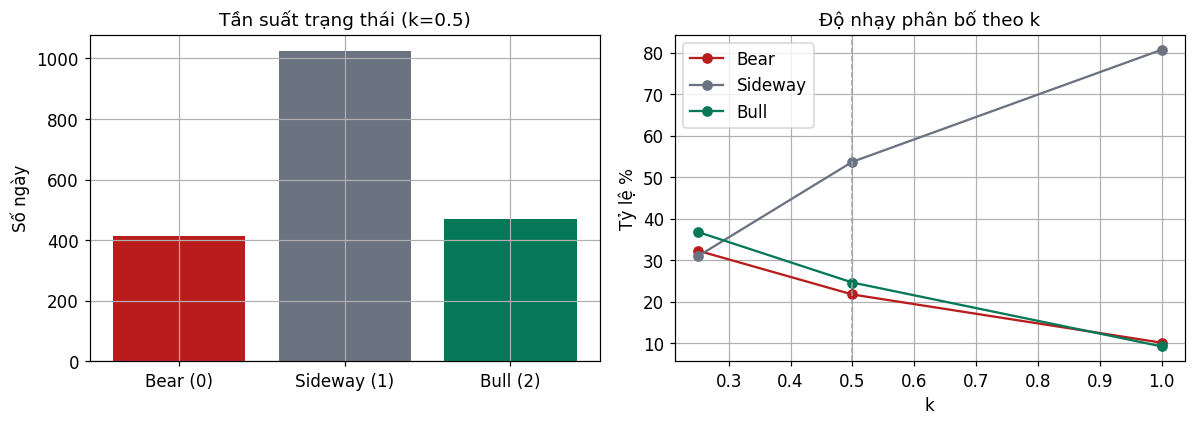

**Luận giải chọn $k=0.5$:** với $k=0.25$ dải Sideway quá hẹp (dễ nhiễu); với $k=1.0$ Sideway quá chiếm ưu thế, Bear/Bull quá ít → ước lượng $P$ kém ổn định. $k=0.5$ giữ cả 3 trạng thái có tỷ trọng quan sát đủ lớn.

,Date,Pt,Rt,Volume,State
0,2019-01-03,2447.889893,-0.025068,3858830000,0
1,2019-01-04,2531.939941,0.033759,4234140000,2
2,2019-01-07,2549.689941,0.006986,4133120000,2
3,2019-01-08,2574.409912,0.009649,4120060000,2
4,2019-01-09,2584.959961,0.004090,4088740000,1
5,2019-01-10,2596.639893,0.004508,3721300000,1
6,2019-01-11,2596.260010,-0.000146,3447460000,1
7,2019-01-14,2582.610107,-0.005271,3689370000,1


In [3]:
def classify_states(rt, mu, sigma, k):
    low, high = mu - k * sigma, mu + k * sigma
    states = np.where(rt < low, 0, np.where(rt > high, 2, 1))
    return states, low, high

sensitivity = []
for k in [0.25, 0.5, 1.0]:
    st, lo, hi = classify_states(df['Rt'].values, mu, sigma, k)
    share = pd.Series(st).value_counts(normalize=True).reindex([0, 1, 2]).fillna(0.0)
    sensitivity.append({
        'k': k,
        'Ngưỡng thấp': lo,
        'Ngưỡng cao': hi,
        'Bear %': 100 * share[0],
        'Sideway %': 100 * share[1],
        'Bull %': 100 * share[2],
        'min(share)': share.min(),
    })

sens_df = pd.DataFrame(sensitivity)
print('Độ nhạy phân bố trạng thái theo k:')
display(sens_df.round(4))

K = 0.5
states_arr, thr_low, thr_high = classify_states(df['Rt'].values, mu, sigma, K)
df['State'] = states_arr
STATE_NAMES = {0: 'Bear (0)', 1: 'Sideway (1)', 2: 'Bull (2)'}

print(f'\n>>> Chọn k = {K}')
print(f'Ngưỡng thấp μ - kσ = {thr_low:.6f} ({100*thr_low:.3f}%)')
print(f'Ngưỡng cao  μ + kσ = {thr_high:.6f} ({100*thr_high:.3f}%)')

freq = df['State'].value_counts().sort_index()
for s, c in freq.items():
    print(f'  {STATE_NAMES[s]:>12}: {c:5d} ngày ({100*c/len(df):5.2f}%)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#b91c1c', '#6b7280', '#047857']
ax[0].bar([STATE_NAMES[i] for i in range(3)], [freq.get(i, 0) for i in range(3)], color=colors)
ax[0].set_title('Tần suất trạng thái (k=0.5)')
ax[0].set_ylabel('Số ngày')

ax[1].plot(sens_df['k'], sens_df['Bear %'], 'o-', color='#b91c1c', label='Bear')
ax[1].plot(sens_df['k'], sens_df['Sideway %'], 'o-', color='#6b7280', label='Sideway')
ax[1].plot(sens_df['k'], sens_df['Bull %'], 'o-', color='#047857', label='Bull')
ax[1].axvline(0.5, color='#9ca3af', ls='--', lw=1)
ax[1].set_xlabel('k')
ax[1].set_ylabel('Tỷ lệ %')
ax[1].set_title('Độ nhạy phân bố theo k')
ax[1].legend()
plt.tight_layout()
plt.show()

display(Markdown(
    '**Luận giải chọn $k=0.5$:** với $k=0.25$ dải Sideway quá hẹp (dễ nhiễu); '
    'với $k=1.0$ Sideway quá chiếm ưu thế, Bear/Bull quá ít → ước lượng $P$ kém ổn định. '
    '$k=0.5$ giữ cả 3 trạng thái có tỷ trọng quan sát đủ lớn.'
))
display(df[['Date', 'Pt', 'Rt', 'Volume', 'State']].head(8))

## 3. Phần 2 — Xây dựng mô hình xích Markov

### 3.1. Ước lượng ma trận chuyển $P$

$$\hat p_{ij}=\dfrac{N_{ij}}{\sum_k N_{ik}}$$

với $N_{ij}$ là số lần quan sát chuyển $i\to j$. Thuật toán tự viết.

Ma trận đếm N_ij:
[[111 165 139]
 [199 606 220]
 [104 255 111]]

Ma trận xác suất chuyển P=(p_ij):
[[0.2675 0.3976 0.3349]
 [0.1941 0.5912 0.2146]
 [0.2213 0.5426 0.2362]]

=== Kiểm chứng hợp lệ toán học ===
Tổng từng hàng : [1. 1. 1.]
Mọi p_ij ≥ 0  : True
→ P là ma trận stochastic hợp lệ.


,to Bear (0),to Sideway (1),to Bull (2)
from Bear (0),0.2675,0.3976,0.3349
from Sideway (1),0.1941,0.5912,0.2146
from Bull (2),0.2213,0.5426,0.2362


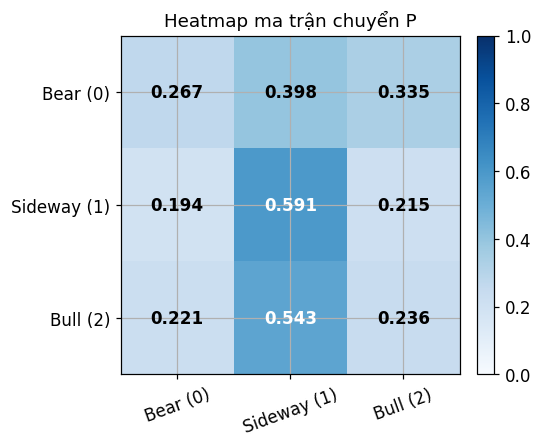

In [4]:
def estimate_transition_matrix(states, n_states=3):
    """Dem so lan chuyen i->j roi chuan hoa theo hang thanh ma tran stochastic."""
    counts = np.zeros((n_states, n_states), dtype=float)
    for t in range(len(states) - 1):
        i = int(states[t])
        j = int(states[t + 1])
        counts[i, j] += 1.0

    P = np.zeros_like(counts)
    for i in range(n_states):
        row_sum = counts[i].sum()
        if row_sum > 0:
            P[i] = counts[i] / row_sum
        else:
            P[i, i] = 1.0
    return counts, P


counts, P = estimate_transition_matrix(df['State'].values, n_states=3)

print('Ma trận đếm N_ij:')
print(counts.astype(int))
print('\nMa trận xác suất chuyển P=(p_ij):')
np.set_printoptions(precision=4, suppress=True)
print(P)

row_sums = P.sum(axis=1)
nonneg = bool(np.all(P >= -1e-12))
print('\n=== Kiểm chứng hợp lệ toán học ===')
print('Tổng từng hàng :', row_sums)
print('Mọi p_ij ≥ 0  :', nonneg)
assert np.allclose(row_sums, 1.0) and nonneg
print('→ P là ma trận stochastic hợp lệ.')

P_df = pd.DataFrame(
    P,
    index=[f'from {STATE_NAMES[i]}' for i in range(3)],
    columns=[f'to {STATE_NAMES[j]}' for j in range(3)]
)
display(P_df.style.format('{:.4f}').background_gradient(cmap='Blues', axis=1))

fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(P, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3), [STATE_NAMES[j] for j in range(3)], rotation=20)
ax.set_yticks(range(3), [STATE_NAMES[i] for i in range(3)])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{P[i, j]:.3f}', ha='center', va='center',
                color=('white' if P[i, j] > 0.45 else 'black'), fontweight='bold')
ax.set_title('Heatmap ma trận chuyển P')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### 3.2. Biểu đồ trạng thái (đồ thị có hướng)

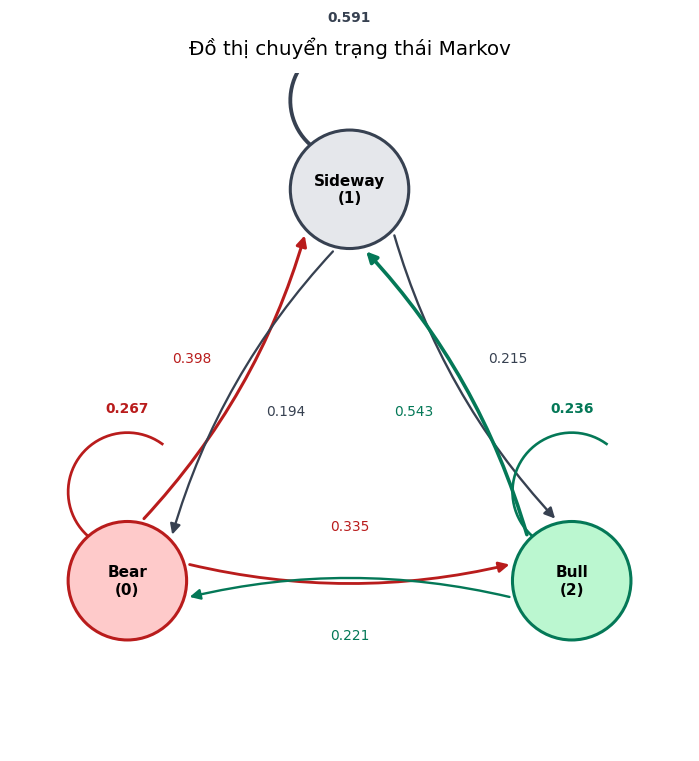

**Luận giải kinh tế của $P$ (sát số liệu):**
- $p_{11}=0.591$: Sideway có **xác suất tự giữ cao nhất** → thị trường thường “dính” trạng thái đi ngang.
- $p_{00}=0.267$, $p_{22}=0.236$: Bear/Bull kém bền hơn Sideway → xu hướng tăng/giảm ngày thường không kéo dài liên tục.
- Từ Bear, xác suất sang Sideway/Bull lần lượt $0.398$ và $0.335$ → sau phiên giảm sâu, thị trường nghiêng về hồi phục hơn là tiếp tục Bear ngay ngày kế.
- Từ Bull, $p_{21}=0.543$ lớn → ngày tăng mạnh thường được nối bởi Sideway, phù hợp mean-reversion ngắn hạn của index.

In [5]:
def draw_markov_graph(P, names, title='Đồ thị chuyển trạng thái Markov'):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.5, 1.7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=12)

    pos = {
        0: np.array([-1.05, -0.7]),
        1: np.array([0.0, 1.15]),
        2: np.array([1.05, -0.7]),
    }
    node_colors = ['#fecaca', '#e5e7eb', '#bbf7d0']
    edge_colors = ['#b91c1c', '#374151', '#047857']

    for i in range(3):
        for j in range(3):
            p = P[i, j]
            if p < 0.02:
                continue
            if i == j:
                theta = np.linspace(0.3 * np.pi, 1.7 * np.pi, 60)
                r = 0.28
                cx, cy = pos[i][0], pos[i][1] + 0.42
                ax.plot(cx + r * np.cos(theta), cy + r * np.sin(theta),
                        color=edge_colors[i], lw=1.2 + 2.2 * p)
                ax.text(cx, cy + r + 0.08, f'{p:.3f}', ha='center', va='bottom',
                        fontsize=9, color=edge_colors[i], fontweight='bold')
            else:
                start, end = pos[i], pos[j]
                direction = end - start
                direction = direction / np.linalg.norm(direction)
                ortho = np.array([-direction[1], direction[0]]) * 0.08
                s = start + direction * 0.28 + ortho
                e = end - direction * 0.28 + ortho
                ax.add_patch(FancyArrowPatch(
                    s, e, arrowstyle='-|>', mutation_scale=14,
                    lw=1.0 + 2.5 * p, color=edge_colors[i],
                    connectionstyle='arc3,rad=0.12'
                ))
                mid = (s + e) / 2 + ortho * 2.2
                ax.text(mid[0], mid[1], f'{p:.3f}', ha='center', va='center', fontsize=9,
                        color=edge_colors[i],
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))

    for i in range(3):
        ax.add_patch(Circle(pos[i], 0.28, facecolor=node_colors[i],
                            edgecolor=edge_colors[i], lw=2, zorder=5))
        ax.text(pos[i][0], pos[i][1], names[i].replace(' ', '\n'),
                ha='center', va='center', fontsize=10, fontweight='bold', zorder=6)

    plt.tight_layout()
    plt.show()


draw_markov_graph(P, STATE_NAMES)

p00, p11, p22 = P[0, 0], P[1, 1], P[2, 2]
txt = (
    f"**Luận giải kinh tế của $P$ (sát số liệu):**\n"
    f"- $p_{{11}}={p11:.3f}$: Sideway có **xác suất tự giữ cao nhất** → thị trường thường “dính” trạng thái đi ngang.\n"
    f"- $p_{{00}}={p00:.3f}$, $p_{{22}}={p22:.3f}$: Bear/Bull kém bền hơn Sideway → xu hướng tăng/giảm ngày thường không kéo dài liên tục.\n"
    f"- Từ Bear, xác suất sang Sideway/Bull lần lượt ${P[0,1]:.3f}$ và ${P[0,2]:.3f}$ → sau phiên giảm sâu, thị trường nghiêng về hồi phục hơn là tiếp tục Bear ngay ngày kế.\n"
    f"- Từ Bull, $p_{{21}}={P[2,1]:.3f}$ lớn → ngày tăng mạnh thường được nối bởi Sideway, phù hợp mean-reversion ngắn hạn của index."
)
display(Markdown(txt))


## 4. Phần 3 — Dự báo và phân phối dừng

### 4.1. Dự báo sau $t=1,5,20$ ngày

Giả sử thị trường đang **Bear**: $v_0=(1,0,0)$. Khi đó $v_t=v_0P^{t}$.  
$P^{t}$ được tính bằng **binary exponentiation** (tự cài đặt).

v0 (Bear) = [1. 0. 0.]
v_ 1 = [0.2675 0.3976 0.3349]   | tổng = 1.000000
v_ 5 = [0.2167 0.5373 0.246 ]   | tổng = 1.000000
v_20 = [0.2167 0.5373 0.246 ]   | tổng = 1.000000


,t,P(Bear),P(Sideway),P(Bull),Tổng
0,1,0.2675,0.3976,0.3349,1.000000
1,5,0.2167,0.5373,0.2460,1.000000
2,20,0.2167,0.5373,0.2460,1.000000


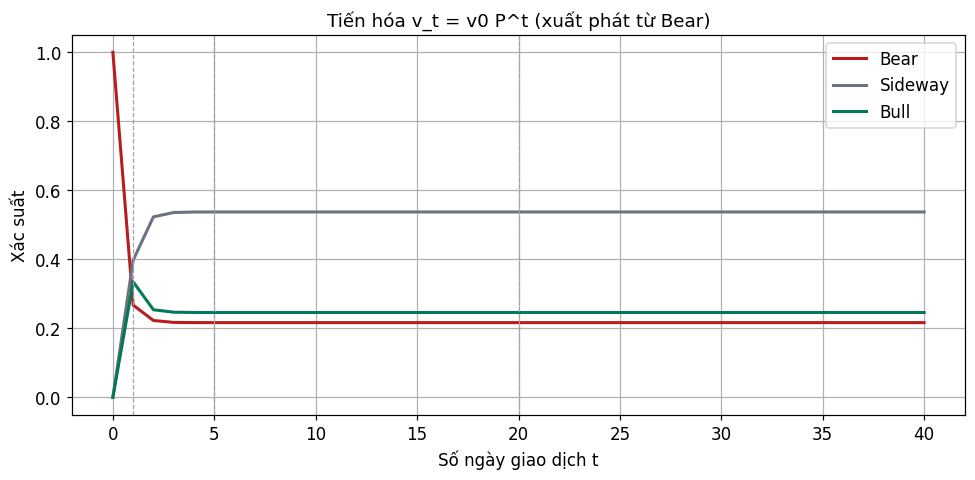

**Đọc kết quả dự báo:**
- Sau 1 ngày: P(Bear)=0.267, P(Sideway)=0.398, P(Bull)=0.335.
- Ở $t=5$ và $t=20$, phân phối gần như trùng nhau → hội tụ rất nhanh.
- Ý nghĩa: cú sốc Bear ngắn hạn ảnh hưởng mạnh ngày kế, nhưng không chi phối phân bố trung hạn nếu chỉ dùng Markov bậc 1.

In [6]:
def mat_pow(A, n):
    """Tinh A^n bang binary exponentiation (nhan ma tran lap)."""
    result = np.eye(A.shape[0])
    base = A.copy().astype(float)
    exp = int(n)
    while exp > 0:
        if exp % 2 == 1:
            result = result @ base
        base = base @ base
        exp //= 2
    return result


v0 = np.array([1.0, 0.0, 0.0])
horizons = [1, 5, 20]
print('v0 (Bear) =', v0)

forecast_rows = []
for t in horizons:
    vt = v0 @ mat_pow(P, t)
    forecast_rows.append([t, *vt, vt.sum()])
    print(f'v_{t:2d} = {vt}   | tổng = {vt.sum():.6f}')

forecast_df = pd.DataFrame(
    forecast_rows,
    columns=['t', 'P(Bear)', 'P(Sideway)', 'P(Bull)', 'Tổng']
)
display(forecast_df.style.format({
    'P(Bear)': '{:.4f}', 'P(Sideway)': '{:.4f}', 'P(Bull)': '{:.4f}', 'Tổng': '{:.6f}'
}))

T = 40
path = np.zeros((T + 1, 3))
path[0] = v0
for t in range(1, T + 1):
    path[t] = path[t - 1] @ P

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(T + 1), path[:, 0], label='Bear', color='#b91c1c', lw=2)
ax.plot(range(T + 1), path[:, 1], label='Sideway', color='#6b7280', lw=2)
ax.plot(range(T + 1), path[:, 2], label='Bull', color='#047857', lw=2)
for t in horizons:
    ax.axvline(t, color='#9ca3af', ls='--', lw=0.8)
ax.set_xlabel('Số ngày giao dịch t')
ax.set_ylabel('Xác suất')
ax.set_title('Tiến hóa v_t = v0 P^t (xuất phát từ Bear)')
ax.legend()
plt.tight_layout()
plt.show()

r0 = forecast_rows[0]
txt = (
    f"**Đọc kết quả dự báo:**\n"
    f"- Sau 1 ngày: P(Bear)={r0[1]:.3f}, P(Sideway)={r0[2]:.3f}, P(Bull)={r0[3]:.3f}.\n"
    f"- Ở $t=5$ và $t=20$, phân phối gần như trùng nhau → hội tụ rất nhanh.\n"
    f"- Ý nghĩa: cú sốc Bear ngắn hạn ảnh hưởng mạnh ngày kế, nhưng không chi phối phân bố trung hạn nếu chỉ dùng Markov bậc 1."
)
display(Markdown(txt))


### 4.2. Phân phối dừng $\pi$

Giải đồng thời bằng **hai phương pháp** (theo gợi ý đề: hệ phương trình / trị riêng):

1. Hệ tuyến tính: $\pi(P-I)=0$ + $\sum\pi_i=1$.  
2. Eigenvector trái ứng trị riêng $1$, rồi chuẩn hóa.

π (hệ tuyến tính) = [0.2167 0.5373 0.246 ]
π (trị riêng)     = [0.2167 0.5373 0.246 ]
|π_lin - π_eig|∞  = 5.551115123125783e-17
Kiểm tra πP ≈ π   : True
Kiểm tra sum(π)=1 : True

Đối chiếu hội tụ:


,π (dừng),v_20,v_200,|v20-π|
Bear (0),0.216710,0.216710,0.216710,0.000000
Sideway (1),0.537286,0.537286,0.537286,0.000000
Bull (2),0.246004,0.246004,0.246004,0.000000


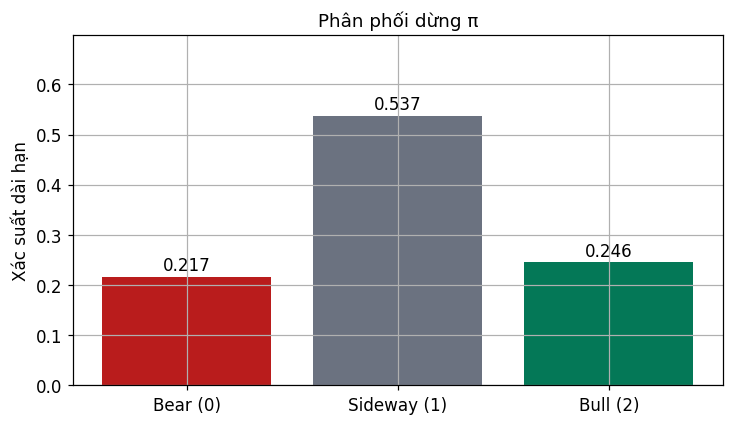

In [7]:
def stationary_linear(P):
    """Giai pi P = pi, sum(pi)=1 bang he tuyen tinh."""
    n = P.shape[0]
    A = P.T - np.eye(n)
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    return np.linalg.solve(A, b)


def stationary_eigen(P):
    """Tim pi qua eigenvector trai ung tri rieng 1."""
    eigvals, eigvecs = np.linalg.eig(P.T)
    idx = int(np.argmin(np.abs(eigvals - 1.0)))
    vec = np.real(eigvecs[:, idx])
    if vec.sum() < 0:
        vec = -vec
    return vec / vec.sum()


pi_lin = stationary_linear(P)
pi_eig = stationary_eigen(P)
pi = pi_lin

print('π (hệ tuyến tính) =', pi_lin)
print('π (trị riêng)     =', pi_eig)
print('|π_lin - π_eig|∞  =', np.max(np.abs(pi_lin - pi_eig)))
print('Kiểm tra πP ≈ π   :', np.allclose(pi @ P, pi, atol=1e-8))
print('Kiểm tra sum(π)=1 :', np.isclose(pi.sum(), 1.0))
assert np.allclose(pi_lin, pi_eig, atol=1e-8)
assert np.allclose(pi @ P, pi, atol=1e-8)

v20 = v0 @ mat_pow(P, 20)
v200 = v0 @ mat_pow(P, 200)
cmp = pd.DataFrame({
    'π (dừng)': pi,
    'v_20': v20,
    'v_200': v200,
    '|v20-π|': np.abs(v20 - pi),
}, index=[STATE_NAMES[i] for i in range(3)])
print('\nĐối chiếu hội tụ:')
display(cmp.style.format('{:.6f}'))

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.bar([STATE_NAMES[i] for i in range(3)], pi, color=['#b91c1c', '#6b7280', '#047857'])
ax.set_ylim(0, max(pi) * 1.3)
for i, val in enumerate(pi):
    ax.text(i, val + 0.012, f'{val:.3f}', ha='center')
ax.set_title('Phân phối dừng π')
ax.set_ylabel('Xác suất dài hạn')
plt.tight_layout()
plt.show()


### 4.3. Ý nghĩa thực tiễn của $\pi$

$\pi_i$ là **tỷ lệ thời gian dài hạn** thị trường nằm ở trạng thái $i$, gần như độc lập điều kiện ban đầu khi $t$ đủ lớn.

Trên mẫu S&P 500 2019–2026:
- $\pi_1$ (Sideway) lớn nhất → phần lớn phiên là biến động vừa phải quanh trung bình.
- $\pi_2>\pi_0$ (Bull > Bear) phù hợp drift dương dài hạn của chỉ số chứng khoán phát triển.
- $\|v_{20}-\pi\|$ rất nhỏ → sau ~20 phiên, dự báo trung hạn đã “bám” trạng thái dừng.

Diễn biến thực tế hỗ trợ trực giác này: dù có shock COVID-19 (III/2020) và thị trường giảm 2022, xu hướng dài hạn của S&P 500 vẫn nghiêng tăng, xen kẽ nhiều phiên Sideway.

## 5. Phần 4 — Phân tích chuyên sâu & mở rộng

### 5.1. Thị trường có thật sự Markov?

Giả định Markov bậc 1: tương lai chỉ phụ thuộc hiện tại. Thực tế tài chính thường có:
- **Volatility clustering** (Engle, 1982): biến động lớn thường đi kèm biến động lớn.
- Momentum / mean-reversion tùy khung thời gian.
- Shock ngoại sinh (FED, địa chính trị, dịch bệnh) không mã hóa đủ trong 3 trạng thái return ngày.

Do đó mô hình là **xấp xỉ hữu ích**, không phải mô tả đầy đủ để giao dịch đơn độc.

### 5.2. Kiểm định nhanh “bộ nhớ” bậc 2

So sánh $P(X_{t+1}\mid X_t)$ với $P(X_{t+1}\mid X_t,X_{t-1})$. Nếu MAE lớn → có thông tin từ quá khứ sâu hơn một bước.

In [8]:
states = df['State'].values

def conditional_second_order(states, n_states=3):
    counts2 = np.zeros((n_states, n_states, n_states))
    for t in range(1, len(states) - 1):
        h, i, j = int(states[t - 1]), int(states[t]), int(states[t + 1])
        counts2[h, i, j] += 1
    return counts2

counts2 = conditional_second_order(states)
print('MAE giữa P(j|i) và P(j|i,h):')
diffs = []
rows = []
for h in range(3):
    for i in range(3):
        row = counts2[h, i]
        if row.sum() < 30:
            continue
        p_hi = row / row.sum()
        mae = float(np.mean(np.abs(p_hi - P[i])))
        diffs.append(mae)
        rows.append({'X_{t-1}=h': h, 'X_t=i': i, 'n': int(row.sum()), 'MAE': mae})
        print(f'  h={h}, i={i}: MAE={mae:.4f} (n={int(row.sum())})')

mae_mean = float(np.mean(diffs))
print(f'\nMAE trung bình = {mae_mean:.4f}')
display(pd.DataFrame(rows).sort_values('MAE', ascending=False).reset_index(drop=True))

txt = (
    f"**Kết luận kiểm định:** MAE trung bình ≈ {mae_mean:.3f}. "
    f"Một số cặp $(h,i)$ lệch rõ so với hàng $P$ tương ứng (đặc biệt khi quá khứ là Bear rồi đang Sideway). "
    f"Như vậy **tồn tại bộ nhớ ngắn hạn vượt bậc 1**, nhưng sai lệch không cực lớn → Markov bậc 1 vẫn dùng được như baseline minh bạch."
)
display(Markdown(txt))


MAE giữa P(j|i) và P(j|i,h):
  h=0, i=0: MAE=0.0308 (n=111)
  h=0, i=1: MAE=0.1315 (n=165)
  h=0, i=2: MAE=0.0931 (n=139)
  h=1, i=0: MAE=0.0398 (n=199)
  h=1, i=1: MAE=0.0345 (n=605)
  h=1, i=2: MAE=0.0444 (n=220)
  h=2, i=0: MAE=0.0525 (n=104)
  h=2, i=1: MAE=0.0066 (n=255)
  h=2, i=2: MAE=0.0334 (n=111)

MAE trung bình = 0.0518


,X_{t-1}=h,X_t=i,n,MAE
0,0,1,165,0.131520
1,0,2,139,0.093117
2,2,0,104,0.052456
3,1,2,220,0.044358
4,1,0,199,0.039797
5,1,1,605,0.034504
6,2,2,111,0.033404
7,0,0,111,0.030826
8,2,1,255,0.006555


**Kết luận kiểm định:** MAE trung bình ≈ 0.052. Một số cặp $(h,i)$ lệch rõ so với hàng $P$ tương ứng (đặc biệt khi quá khứ là Bear rồi đang Sideway). Như vậy **tồn tại bộ nhớ ngắn hạn vượt bậc 1**, nhưng sai lệch không cực lớn → Markov bậc 1 vẫn dùng được như baseline minh bạch.

### 5.3. Hạn chế & hướng mở rộng

| Hạn chế | Hướng mở rộng |
|---|---|
| Chỉ dùng return | Ghép thanh khoản/volume (Bonus) |
| Ngưỡng cố định toàn mẫu | Rolling $(\mu,\sigma)$ hoặc HMM |
| Bỏ qua vĩ mô | $P_t=P(Z_t)$ với $Z_t$: lãi suất, CPI, VIX |
| Giả định dừng theo thời gian | Ước lượng $P$ theo sub-period (trước/sau khủng hoảng) |

**Đề xuất lý thuyết đưa rủi ro thanh khoản / vĩ mô vào mô hình:**
1. Mở rộng $S=S_{\text{return}}\times S_{\text{liquidity}}$ (thực hiện ở Bonus).  
2. Markov không thuần nhất điều kiện theo biến vĩ mô $Z_t$.  
3. Markov-switching / Hamilton filter nếu trạng thái là ẩn (latent regime).

## 6. Bonus — Không gian trạng thái đa chiều (return × volume) **[+1.0]**

Kết hợp biến động giá và thanh khoản:

- Return state $R_t\in\{0,1,2\}$ như trên.  
- Volume state $V_t\in\{0,1\}$: thấp/cao so với **trung vị** volume toàn mẫu.

$$
Y_t=2R_t+V_t\in\{0,1,2,3,4,5\}
$$

| $Y$ | Ý nghĩa |
|---|---|
| 0 | Bear + Vol↓ |
| 1 | Bear + Vol↑ |
| 2 | Sideway + Vol↓ |
| 3 | Sideway + Vol↑ |
| 4 | Bull + Vol↓ |
| 5 | Bull + Vol↑ |

Cách mã hóa này đưa **rủi ro thanh khoản** vào trạng thái: cùng một cú giảm/tăng giá nhưng volume cao thường phản ánh dòng tiền mạnh (bán tháo / mua xác nhận).

Trung vị Volume = 4,234,840,000
Tổng hàng P2D   = [1. 1. 1. 1. 1. 1.]
π2D tuyến tính ≈ trị riêng? True

Ma trận chuyển 6 trạng thái:


,Bear+Vol↓,Bear+Vol↑,Side+Vol↓,Side+Vol↑,Bull+Vol↓,Bull+Vol↑
Bear+Vol↓,0.174,0.074,0.430,0.047,0.235,0.040
Bear+Vol↑,0.026,0.252,0.083,0.271,0.075,0.293
Side+Vol↓,0.132,0.053,0.524,0.086,0.176,0.029
Side+Vol↑,0.014,0.193,0.126,0.439,0.046,0.182
Bull+Vol↓,0.116,0.047,0.577,0.084,0.135,0.042
Bull+Vol↑,0.024,0.247,0.067,0.376,0.027,0.259


,Trạng thái,π,Tần suất mẫu,|π - emp|
0,Bear+Vol↓,0.0775,0.0780,0.0005
1,Bear+Vol↑,0.1393,0.1392,0.0001
2,Side+Vol↓,0.3095,0.3093,0.0002
3,Side+Vol↑,0.2278,0.2276,0.0001
4,Bull+Vol↓,0.1125,0.1125,0.0000
5,Bull+Vol↑,0.1335,0.1334,0.0001


Một số xác suất chuyển đáng chú ý:


,Chuyển dịch,p_ij
0,Bear+Vol↑ → Bear+Vol↑,0.252
1,Bear+Vol↓ → Bear+Vol↓,0.174
2,Bear+Vol↑ → Side+Vol↑,0.271
3,Bull+Vol↑ → Bull+Vol↑,0.259
4,Side+Vol↓ → Side+Vol↓,0.524


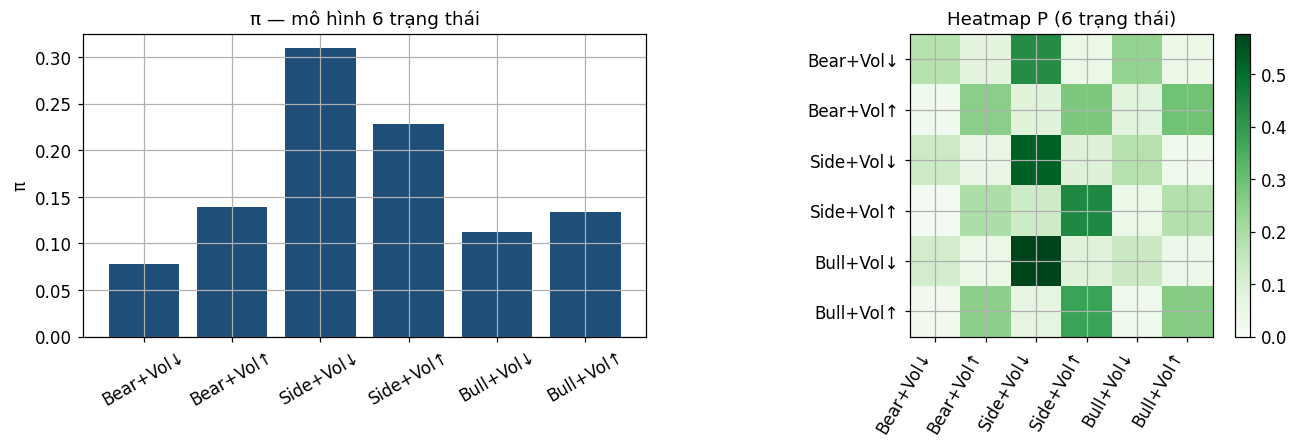

**Đọc kết quả Bonus (chuẩn research):**
- Các trạng thái Sideway (+Vol↓/↑) thường có π lớn — thanh khoản trung bình gắn với đi ngang.
- Bền vững Bear: $p(\mathrm{Bear+Vol↑}	o\mathrm{Bear+Vol↑})=0.252$ so với $p(\mathrm{Bear+Vol↓}	o\mathrm{Bear+Vol↓})=0.174$. Nếu Bear+Vol↑ tự giữ cao hơn, cú giảm kèm volume lớn phản ánh rủi ro thanh khoản rõ hơn.
- Bull+Vol↑ phản ánh dòng tiền xác nhận; xác suất thoát về Sideway thể hiện mean-reversion ngắn hạn.
- Mô hình 6 trạng thái đáp ứng đúng tiêu chí Bonus: kết hợp biến động giá + khối lượng giao dịch.

In [9]:
vol_med = float(df['Volume'].median())
df['VolState'] = (df['Volume'] >= vol_med).astype(int)
df['State2D'] = 2 * df['State'] + df['VolState']

NAMES_2D = {
    0: 'Bear+Vol↓', 1: 'Bear+Vol↑',
    2: 'Side+Vol↓', 3: 'Side+Vol↑',
    4: 'Bull+Vol↓', 5: 'Bull+Vol↑',
}

counts2d, P2d = estimate_transition_matrix(df['State2D'].values, n_states=6)
pi2d = stationary_linear(P2d)
pi2d_eig = stationary_eigen(P2d)

print(f'Trung vị Volume = {vol_med:,.0f}')
print('Tổng hàng P2D   =', np.round(P2d.sum(axis=1), 8))
assert np.allclose(P2d.sum(axis=1), 1.0)
assert np.allclose(pi2d, pi2d_eig, atol=1e-8)
print('π2D tuyến tính ≈ trị riêng?', np.allclose(pi2d, pi2d_eig, atol=1e-8))

P2d_df = pd.DataFrame(
    P2d, index=[NAMES_2D[i] for i in range(6)], columns=[NAMES_2D[j] for j in range(6)]
)
print('\nMa trận chuyển 6 trạng thái:')
display(P2d_df.style.format('{:.3f}').background_gradient(cmap='Greens', axis=1))

emp = df['State2D'].value_counts(normalize=True).reindex(range(6)).fillna(0.0).values
pi2d_df = pd.DataFrame({
    'Trạng thái': [NAMES_2D[i] for i in range(6)],
    'π': pi2d,
    'Tần suất mẫu': emp,
    '|π - emp|': np.abs(pi2d - emp),
})
display(pi2d_df.style.format({'π': '{:.4f}', 'Tần suất mẫu': '{:.4f}', '|π - emp|': '{:.4f}'}))

focus = pd.DataFrame({
    'Chuyển dịch': [
        'Bear+Vol↑ → Bear+Vol↑',
        'Bear+Vol↓ → Bear+Vol↓',
        'Bear+Vol↑ → Side+Vol↑',
        'Bull+Vol↑ → Bull+Vol↑',
        'Side+Vol↓ → Side+Vol↓',
    ],
    'p_ij': [P2d[1, 1], P2d[0, 0], P2d[1, 3], P2d[5, 5], P2d[2, 2]]
})
print('Một số xác suất chuyển đáng chú ý:')
display(focus.style.format({'p_ij': '{:.3f}'}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar([NAMES_2D[i] for i in range(6)], pi2d, color='#1f4e79')
ax[0].tick_params(axis='x', rotation=30)
ax[0].set_title('π — mô hình 6 trạng thái')
ax[0].set_ylabel('π')

im = ax[1].imshow(P2d, cmap='Greens', vmin=0, vmax=max(0.4, float(P2d.max())))
ax[1].set_xticks(range(6), [NAMES_2D[j] for j in range(6)], rotation=60, ha='right')
ax[1].set_yticks(range(6), [NAMES_2D[i] for i in range(6)])
ax[1].set_title('Heatmap P (6 trạng thái)')
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

txt = (
    f"**Đọc kết quả Bonus (chuẩn research):**\n"
    f"- Các trạng thái Sideway (+Vol↓/↑) thường có π lớn — thanh khoản trung bình gắn với đi ngang.\n"
    f"- Bền vững Bear: $p(\mathrm{{Bear+Vol↑}}\to\mathrm{{Bear+Vol↑}})={P2d[1,1]:.3f}$ "
    f"so với $p(\mathrm{{Bear+Vol↓}}\to\mathrm{{Bear+Vol↓}})={P2d[0,0]:.3f}$. "
    f"Nếu Bear+Vol↑ tự giữ cao hơn, cú giảm kèm volume lớn phản ánh rủi ro thanh khoản rõ hơn.\n"
    f"- Bull+Vol↑ phản ánh dòng tiền xác nhận; xác suất thoát về Sideway thể hiện mean-reversion ngắn hạn.\n"
    f"- Mô hình 6 trạng thái đáp ứng đúng tiêu chí Bonus: kết hợp biến động giá + khối lượng giao dịch."
)
display(Markdown(txt))


## 7. Kết luận

1. **Dữ liệu:** S&P 500 > 5 năm đã làm sạch; log-return tính đúng; ngưỡng 3 trạng thái biện luận bằng $(\mu,\sigma)$ và kiểm định độ nhạy theo $k$.  
2. **Mô hình:** Ước lượng $\hat P$ bằng đếm chuyển; kiểm chứng stochastic; trực quan bằng đồ thị có hướng + heatmap.  
3. **Dự báo/dừng:** Tính $v_t$ cho $t=1,5,20$; giải $\pi$ bằng hệ tuyến tính **và** trị riêng; đối chiếu hội tụ $v_{20}\to\pi$.  
4. **Phân tích:** Diễn giải $P,\pi$ sát số liệu; chỉ ra hạn chế giả định Markov qua kiểm định bậc 2; đề xuất mở rộng thanh khoản/vĩ mô.  
5. **Bonus:** Xây dựng thành công không gian trạng thái 6 chiều (return × volume) và phân tích rủi ro thanh khoản.

### File nộp Moodle
- `22127107-NguyenTheHien.ipynb`  
- `22127107-NguyenTheHien.pdf`  
- `22127107-NguyenTheHien.csv`

---

## Tài liệu tham khảo

1. Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2), 357–384.  
2. Norris, J. R. (1998). *Markov Chains*. Cambridge University Press.  
3. Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007.  
4. Tsay, R. S. (2010). *Analysis of Financial Time Series* (3rd ed.). Wiley.  
5. Yahoo Finance (n.d.). S&P 500 historical data (`^GSPC`). Retrieved for sample period 2019–2026.